In [3]:
from setuptools.monkey import patch_all
%load_ext autoreload
%autoreload 2
import pandas as pd
from IPython.display import display, HTML

from src.data_loader import load_and_clean_data, load_top_200, merge_with_top_200
from src.analysis import *
from src.visualizations import *

display(HTML("<style>.container { width:100% !important; }</style>"))
pd.set_option('display.expand_frame_repr', False)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
df = load_and_clean_data("../data/raw")
df = add_time_features(df) # Funkcja z analysis.py

df_t200 = load_top_200('../data/raw/data.csv')

# Złączenie z Top 200 (wykorzystujemy Twoją gotową funkcję z data_loader.py!)
df_final_200 = merge_with_top_200(df, df_t200)

print(f"Udało się dopasować odtworzenia do rankingu Top 200.")
df_final_200.info()


Udało się dopasować odtworzenia do rankingu Top 200.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37882 entries, 0 to 37881
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          37882 non-null  datetime64[ns]
 1   duration           37882 non-null  object        
 2   song               37667 non-null  object        
 3   artist             37667 non-null  object        
 4   album              37667 non-null  object        
 5   country            37882 non-null  object        
 6   device             37882 non-null  object        
 7   ms_played          37882 non-null  int64         
 8   track_id           37667 non-null  object        
 9   reason_start       37882 non-null  object        
 10  reason_end         37882 non-null  object        
 11  shuffle            37882 non-null  bool          
 12  skipped            37882 non-null  bool          
 13  offline 

In [ ]:
top_artist = get_top_ranking(df, "artist", 10)
top_song = get_top_ranking(df, "song", 15)
top_album = get_top_albums(df, 15)

display(top_artist.head())

plot_top_artists_bar(top_artist)
plot_lollipop_top_songs(top_song, title='Top Utwory: Godziny i Częstotliwość')
plot_songs_scatter(top_song)


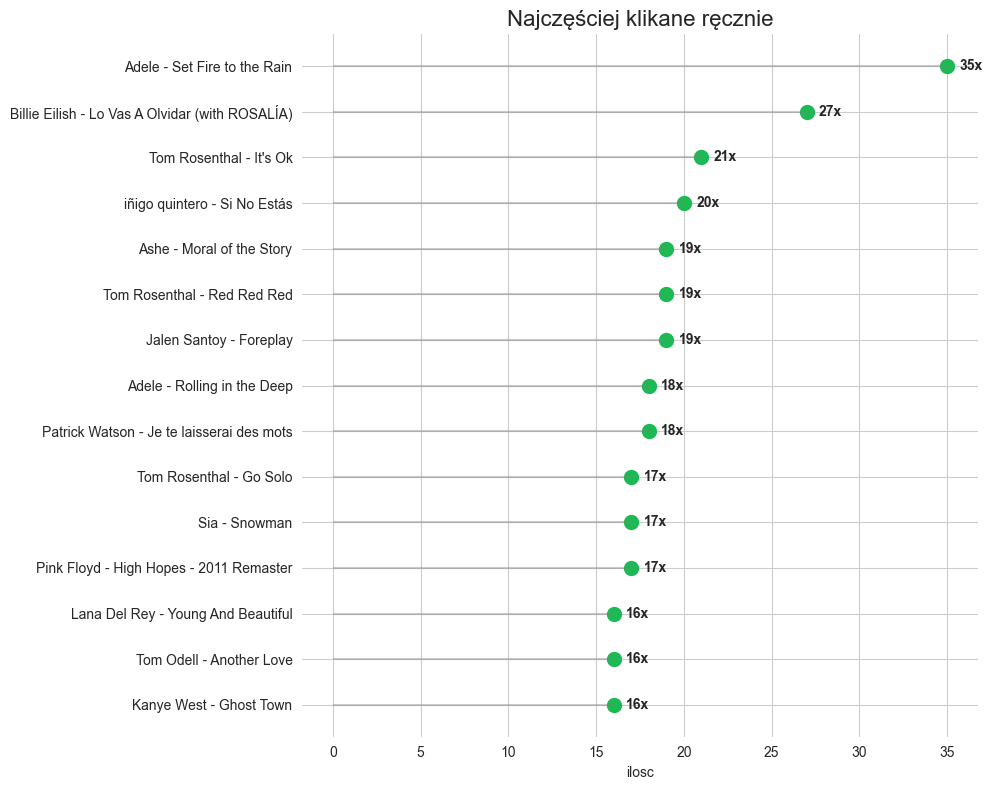

,index,artist,song,skip_count,total_plays,skips%rate
0,3293,Joji,ATTENTION,12,14,85.714286
1,4712,Matt Maltese,Strange Time,21,26,80.769231
2,2241,Fleet Foxes,Mykonos,8,10,80.000000
3,2764,Harry Styles,Watermelon Sugar,11,14,78.571429
4,1692,Declan McKenna,Isombard,10,13,76.923077
5,2726,Happysad,Zanim pójdę,13,17,76.470588
6,7580,Tom Rosenthal,Red Red Red,15,20,75.000000
7,1637,Dawid Podsiadło,Nie Kłami,9,12,75.000000
8,1202,Cavetown,Lemon Boy,9,12,75.000000
9,3952,Lana Del Rey,Brooklyn Baby,14,19,73.684211


In [9]:
most_clicked = get_top_played_by_reason(df,'clickrow', 15)

skips = df[df['reason_end'] == 'fwdbtn']
most_annoying = get_skips_analysis(skips, time_threshold_ms=3000, min_plays=10)

plot_horizontal_lollipop(most_clicked, x_col='ilosc', y_col='label', label_col='ilosc', title='Najczęściej klikane ręcznie')
display(most_annoying.head(10))



Prawdopodobieństwo, że piosenka będzie populrne:
reason_start
unknown       33.33%
playbtn       19.67%
clickrow      19.26%
appload       19.11%
trackdone     19.07%
trackerror    18.92%
fwdbtn        18.51%
backbtn       16.82%
remote        11.60%
Name: global_hit, dtype: object


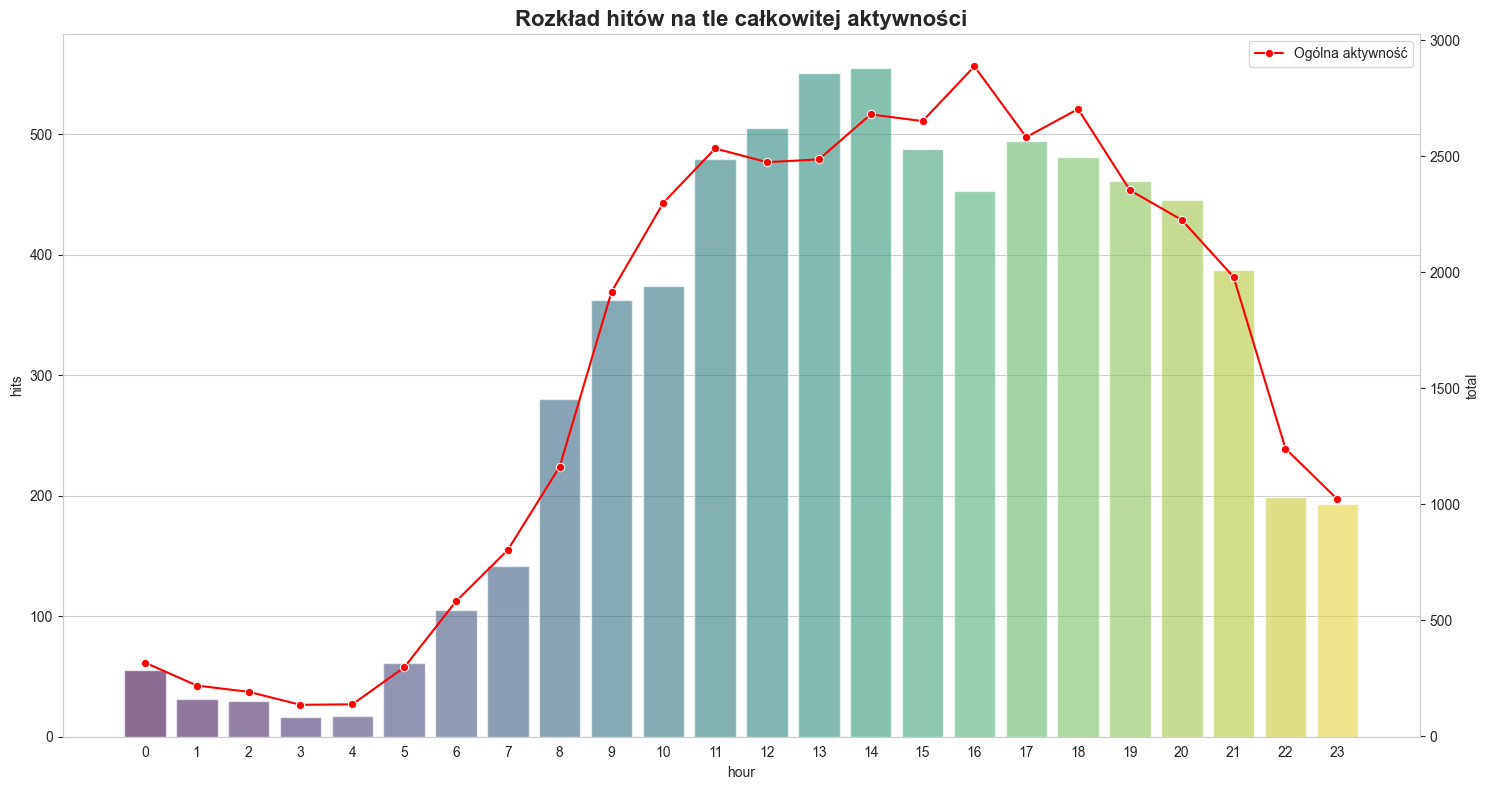

In [11]:
# Klasyfikacja odkryć
df_final_200 = get_discovery_types(df_final_200)

# Hit density
hit_density = df_final_200.groupby('reason_start')['global_hit'].mean() * 100
print("\nPrawdopodobieństwo, że piosenka będzie populrne:")
print(hit_density.sort_values(ascending=False).apply(lambda x: f"{x:.2f}%"))

# Wykres czasowy pipularnych vs Całkowita aktywność
df_only_popular = df_final_200[df_final_200['global_hit'] == True].copy()
fig_dual = plot_dual_activity(df_final_200, df_only_popular)
plt.show()


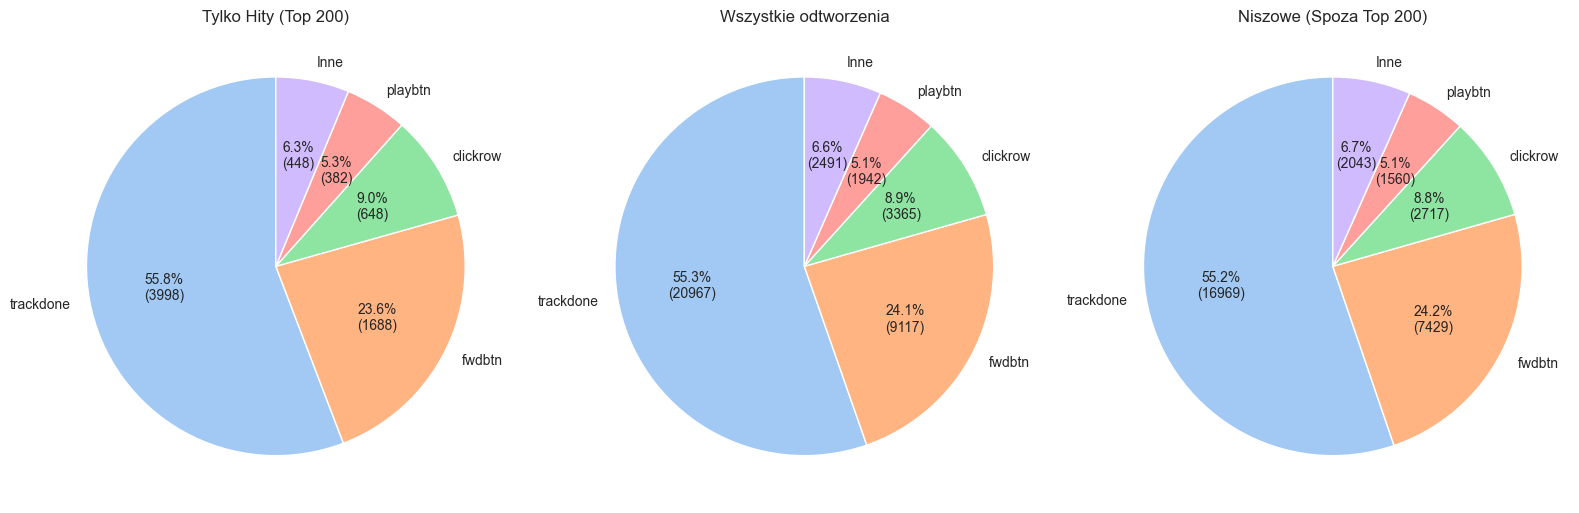

In [12]:
df_not_popular = df_final_200[df_final_200['global_hit'] == False]

powody_hity = prepare_pie_data(df_only_popular['reason_start'])
powody_wszystko = prepare_pie_data(df_final_200['reason_start'])
powody_nisza = prepare_pie_data(df_not_popular['reason_start'])

plot_comparison_pies(
    powody_list=[powody_hity, powody_wszystko, powody_nisza],
    titles=['Tylko Hity (Top 200)', 'Wszystkie odtworzenia', 'Niszowe (Spoza Top 200)']
)